# Deep Dive Analysis: Momentum Search Optimization (Top 15 vs Top 30)

Notebook ini melakukan perbandingan sensitivitas terhadap pembatasan jumlah aset pada tahap **Momentum Sort** sebelum pengolahan Graph.

**Skenario yang Diuji:**
1. **Top 30 Selection**: Universe yang lebih luas, memberikan lebih banyak ruang bagi Graph Theory untuk menemukan hubungan korelasi.
2. **Top 15 Selection**: Universe yang sangat selektif, hanya fokus pada koin-koin dengan tren terkuat (High Conviction).
3. **Comparison Focus**: Melihat bagaimana pembatasan ini mempengaruhi Return, Sharpe, dan Asset Diversity di tahun 2025.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
from scipy.optimize import minimize
import networkx as nx
from sklearn.metrics import fbeta_score
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

plt.style.use('ggplot')
sns.set_palette("husl")

SEED = 42
np.random.seed(SEED)

print("✓ Environment Ready for Multi-Scenario Momentum Analysis!")

✓ Environment Ready for Multi-Scenario Momentum Analysis!


## 1. Load Data & Setup

In [2]:
# Load cryptocurrency data
file_path = '../experiment_nextLevel2/dataset_2023_2025.xlsx'
data = pd.read_excel(file_path, index_col=0, parse_dates=True)
returns = data.pct_change().dropna()
market_return = returns.mean(axis=1)
market_index = (1 + market_return).cumprod() * 100

print(f"Data: {len(data)} rows, {len(data.columns)} assets")

Data: 990 rows, 25 assets


## 2. Model Training & Probabilities

In [3]:
# Prepare features
features = pd.DataFrame(index=returns.index)
features['Vol_20'] = market_return.rolling(window=20).std()
features['Mom_20'] = market_return.rolling(window=20).mean()
features['Mom_50'] = market_return.rolling(window=50).mean()

sma5 = market_return.rolling(window=5).mean()
sma20 = market_return.rolling(window=20).mean()
target = (sma5 > sma20).astype(int).shift(-5).reindex(features.index).fillna(0)

# Train model (up to 2024)
X_train = features.loc[features.index.year <= 2024].dropna()
y_train = target.loc[X_train.index]
xgb_model = xgb.XGBClassifier(n_estimators=100, learning_rate=0.05, max_depth=5, 
                              random_state=SEED, eval_metric='logloss')
xgb_model.fit(X_train, y_train)

# Threshold Optimization (Reuse previously found 0.52)
opt_t = 0.52

# Probabilities
X_all = features.dropna()
all_probs = pd.Series(xgb_model.predict_proba(X_all)[:, 1], index=X_all.index)
all_probs = all_probs.reindex(returns.index, method='ffill').fillna(method='bfill')

print(f"✓ AI Ready.")

✓ AI Ready.


## 3. Dynamic Selection Functions
Logika ini memungkinkan kita mengubah parameter `top_n` secara dinamis.

In [4]:
def optimize_markowitz(selected_returns):
    if len(selected_returns.columns) == 0: return {}
    if len(selected_returns.columns) == 1: return {selected_returns.columns[0]: 1.0}
    mu = selected_returns.mean() * 252
    sigma = selected_returns.cov() * 252
    num_assets = len(mu)
    def objective(w):
        ret = np.sum(w * mu)
        risk = np.sqrt(np.dot(w.T, np.dot(sigma, w)))
        if risk < 0.0001: return 0
        return -(ret / risk)
    constraints = ({'type': 'eq', 'fun': lambda x: np.sum(x) - 1})
    bounds = tuple((0, 1) for _ in range(num_assets))
    res = minimize(objective, [1./num_assets]*num_assets, method='SLSQP', bounds=bounds, constraints=constraints)
    return dict(zip(selected_returns.columns, res.x)) if res.success else {}

def get_assets_graph_selection(returns_window, corr_threshold=0.4, top_n=25, strategy_type='diversify'):
    # 1. Momentum Stage
    momentum_assets = returns_window.mean().sort_values(ascending=False).head(top_n).index
    returns_mom = returns_window[momentum_assets]
    
    # 2. Graph Stage
    corr_mat = returns_mom.corr()
    G = nx.Graph()
    G.add_nodes_from(momentum_assets)
    for i, a1 in enumerate(momentum_assets):
        for a2 in momentum_assets[i+1:]:
            if strategy_type == 'diversify':
                if abs(corr_mat.loc[a1, a2]) > corr_threshold: G.add_edge(a1, a2)
            else: # cluster
                if abs(corr_mat.loc[a1, a2]) < corr_threshold: G.add_edge(a1, a2)
    
    return list(nx.approximation.maximum_independent_set(G))

def run_simulation_scenarios(test_dates, returns, ai_probs, threshold, market_idx, top_n, strategy_type, fee=0.0025):
    val = 100.0; history = [val]; dates = [test_dates[0]]
    current_weights = {}; risk_status = False; days_since_rebal = 999
    market_ma = market_idx.rolling(window=200).mean()

    for i, date in enumerate(test_dates[:-1]):
        prob = ai_probs.loc[date]
        prev_risk = risk_status
        if not risk_status and prob > (threshold + 0.05): risk_status = True
        elif risk_status and prob < (threshold - 0.05): risk_status = False
        
        if market_idx.loc[date] > market_ma.loc[date]: risk_status = True
            
        regime_changed = (risk_status != prev_risk)
        target_weights = current_weights.copy()
        
        if not risk_status:
            target_weights = {'CASH': 1.0}; days_since_rebal = 0
        else:
            if regime_changed or days_since_rebal >= 20:
                try:
                    loc_idx = returns.index.get_loc(date)
                    window = returns.iloc[max(0, loc_idx-60):loc_idx]
                    selected = get_assets_graph_selection(window, top_n=top_n, strategy_type=strategy_type)
                    if selected:
                        target_weights = optimize_markowitz(window[selected])
                        days_since_rebal = 0
                except: pass
        
        days_since_rebal += 1
        turnover = sum(abs(target_weights.get(k, 0) - current_weights.get(k, 0)) for k in set(target_weights)|set(current_weights))
        val -= val * turnover * fee
        
        next_date = test_dates[i+1]
        day_ret = 0; new_drifted = {}
        if 'CASH' in target_weights: 
            new_drifted = {'CASH': 1.0}
        else:
            for asset, w in target_weights.items():
                day_ret += w * (returns.loc[next_date, asset] if next_date in returns.index else 0)
                new_drifted[asset] = w * (1 + (returns.loc[next_date, asset] if next_date in returns.index else 0))
        
        val *= (1 + day_ret)
        history.append(val); dates.append(next_date)
        current_weights = {k: v/sum(new_drifted.values()) for k, v in new_drifted.items()} if sum(new_drifted.values()) > 0 else new_drifted
        
    return pd.DataFrame({'Portfolio_Value': history}, index=dates)

## 4. Pelaksanaan Eksperimen (Tahun 2025 Fokus)
Membandingkan keunggulan pembatasan aset yang berbeda.

In [5]:
test_dates_2025 = returns.loc[returns.index.year == 2025].index
scenarios = [15, 30]
scenario_results = {}
metrics_compare = []

for n in scenarios:
    print(f"Running Scenario: Top {n} Momentum Assets...")
    val_div = run_simulation_scenarios(test_dates_2025, returns, all_probs, opt_t, market_index, n, 'diversify')
    val_cls = run_simulation_scenarios(test_dates_2025, returns, all_probs, opt_t, market_index, n, 'cluster')
    
    scenario_results[n] = {'Div': val_div, 'Cls': val_cls}
    
    for name, v in [('Diversify', val_div), ('Cluster', val_cls)]:
        ret = (v['Portfolio_Value'].iloc[-1]/100 - 1)*100
        vol = v['Portfolio_Value'].pct_change().std()*np.sqrt(252)*100
        sharpe = ret/vol if vol > 0 else 0
        metrics_compare.append({'Scenario': f'Top {n}', 'Strategy': name, 'Return': ret, 'Sharpe': sharpe})

metrics_df = pd.DataFrame(metrics_compare)
print("✓ All scenarios simulated for 2025.")

Running Scenario: Top 15 Momentum Assets...
Running Scenario: Top 30 Momentum Assets...
✓ All scenarios simulated for 2025.


## 5. Visualisasi Gabungan: Top 15 vs Top 30

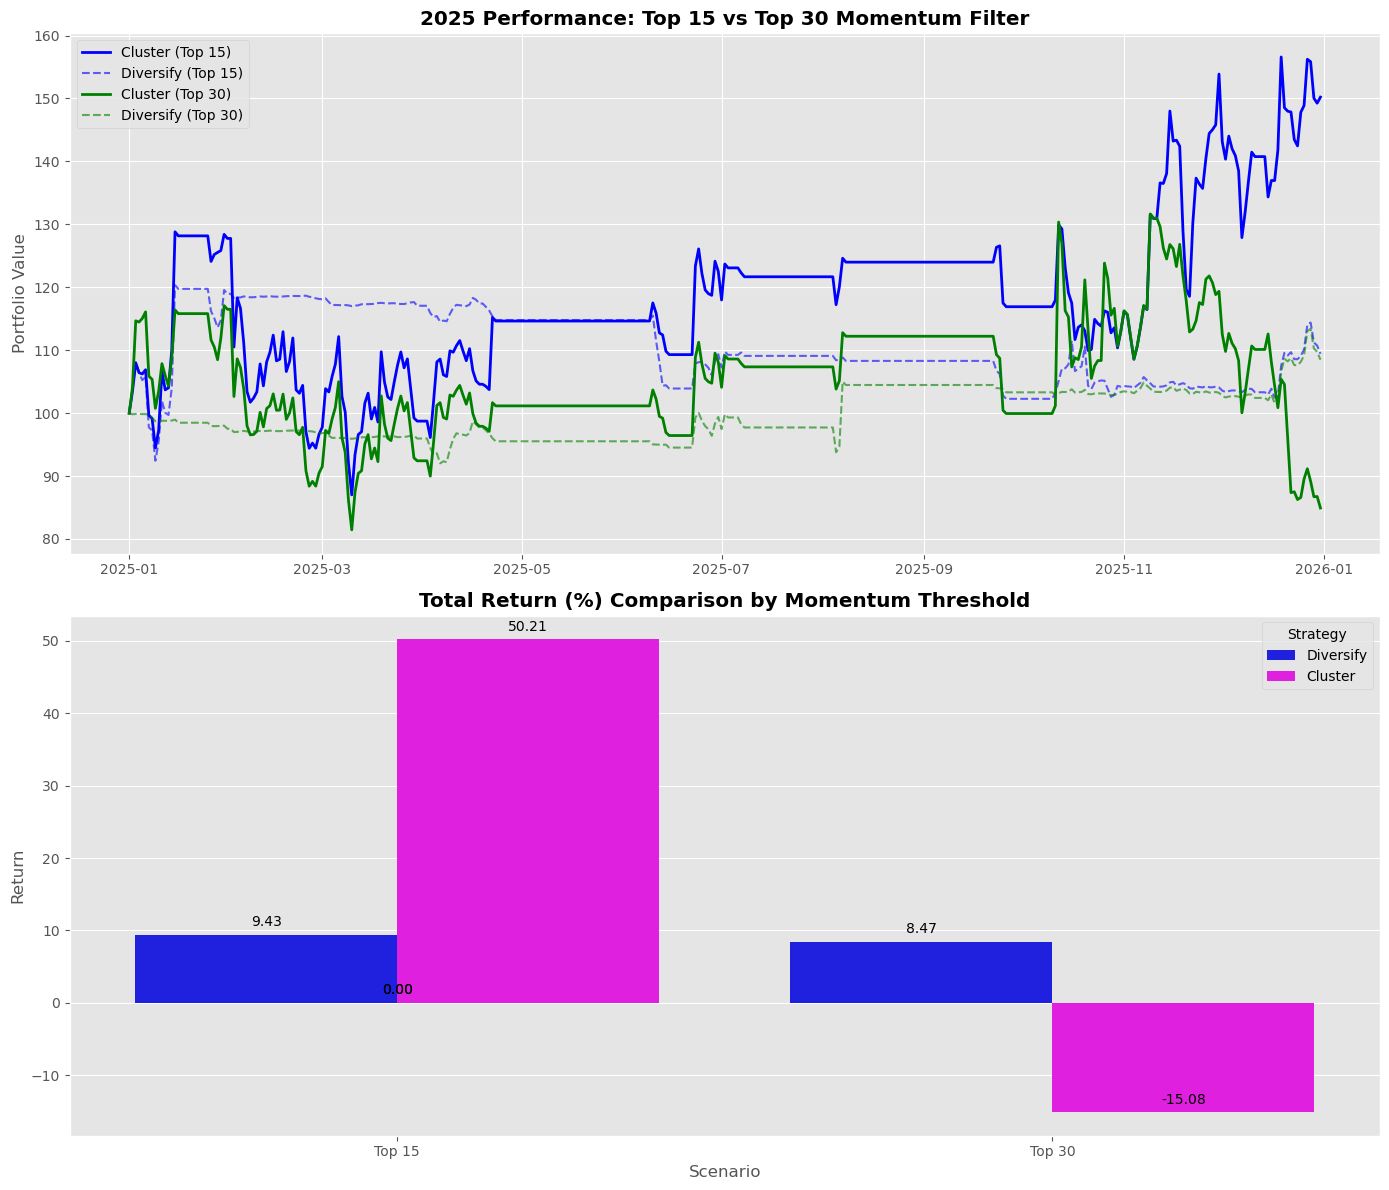

In [6]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 12))

# 1. Performance Curve
colors = {15: 'blue', 30: 'green'}
for n in scenarios:
    ax1.plot(scenario_results[n]['Cls'].index, scenario_results[n]['Cls']['Portfolio_Value'], 
             label=f'Cluster (Top {n})', color=colors[n], linewidth=2)
    ax1.plot(scenario_results[n]['Div'].index, scenario_results[n]['Div']['Portfolio_Value'], 
             label=f'Diversify (Top {n})', color=colors[n], linestyle='--', alpha=0.6)

ax1.set_title("2025 Performance: Top 15 vs Top 30 Momentum Filter", fontweight='bold')
ax1.set_ylabel("Portfolio Value")
ax1.legend()

# 2. Metrics Comparison
sns.barplot(data=metrics_df, x='Scenario', y='Return', hue='Strategy', ax=ax2, palette=['blue', 'magenta'])
ax2.set_title("Total Return (%) Comparison by Momentum Threshold", fontweight='bold')

for p in ax2.patches:
    ax2.annotate(format(p.get_height(), '.2f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points', fontsize=10)

plt.tight_layout()
plt.savefig('momentum_threshold_comparison.png')
plt.show()